<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron

from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical

In [4]:
df = pd.read_csv("/content/drive/MyDrive/dataset/mnist_train.csv")
df_test = pd.read_csv("/content/drive/MyDrive/dataset/mnist_test.csv")

In [5]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df_test.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df.shape

(60000, 785)

In [10]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [13]:
X_train = df.drop(['label'],axis=1).values
y_train = df['label']
X_test = df_test.drop(['label'],axis=1).values
y_test = df_test['label']

In [14]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [15]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [19]:
y_train_cat = to_categorical(y_train , 10)
y_test_cat = to_categorical(y_test , 10)

In [17]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation='softmax')
])

In [18]:
perceptron.compile(optimizer="sgd" , loss="categorical_crossentropy" , metrics=["accuracy"])

In [20]:
hist_percp = perceptron.fit(X_train_img , y_train_cat , epochs=50 ,
batch_size=32 , validation_data=(X_test_img , y_test_cat) , verbose=1)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8176 - loss: 0.7746 - val_accuracy: 0.8817 - val_loss: 0.4776
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8817 - loss: 0.4546 - val_accuracy: 0.8951 - val_loss: 0.3982
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8918 - loss: 0.4024 - val_accuracy: 0.9025 - val_loss: 0.3661
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8978 - loss: 0.3762 - val_accuracy: 0.9074 - val_loss: 0.3470
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9011 - loss: 0.3595 - val_accuracy: 0.9094 - val_loss: 0.3351
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9038 - loss: 0.3479 - val_accuracy: 0.9113 - val_loss: 0.3255
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9059 - loss: 0.3389 - val_accuracy: 0.9143 - val_loss: 0.3185
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9084 - loss: 0.3318 - 

In [21]:
acc_percp = perceptron.evaluate(X_test_img , y_test_cat , verbose=0)[1]
acc_percp

0.9222999811172485

In [22]:
#ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [23]:
ann.compile(optimizer="adam" , loss="categorical_crossentropy" , metrics=["accuracy"])

In [24]:
history_ann = ann.fit(X_train_img , y_train_cat , epochs=50 ,
batch_size=32 , validation_data=(X_test_img , y_test_cat) , verbose=1)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9284 - loss: 0.2431 - val_accuracy: 0.9653 - val_loss: 0.1165
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9684 - loss: 0.1045 - val_accuracy: 0.9705 - val_loss: 0.0930
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9769 - loss: 0.0733 - val_accuracy: 0.9741 - val_loss: 0.0843
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9826 - loss: 0.0549 - val_accuracy: 0.9740 - val_loss: 0.0842
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9854 - loss: 0.0443 - val_accuracy: 0.9785 - val_loss: 0.0738
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9891 - loss: 0.0338 - val_accuracy: 0.9773 - val_loss: 0.0772
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9912 - loss: 0.0277 - val_accuracy: 0.9757 - val_loss: 0.0888
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9912 - loss: 0.0267 -

In [26]:
acc_ann = ann.evaluate(X_test_img , y_test_cat , verbose=0)[1]
acc_ann

0.9807000160217285

In [28]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [27]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [29]:
cnn.compile(optimizer="adam" , loss="categorical_crossentropy" , metrics=["accuracy"])

In [31]:
history_cnn = cnn.fit(X_train_cnn , y_train_cat , epochs=5 ,
batch_size=32 , validation_data=(X_test_cnn , y_test_cat) , verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9781 - loss: 0.0708 - val_accuracy: 0.9836 - val_loss: 0.0475
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9870 - loss: 0.0415 - val_accuracy: 0.9897 - val_loss: 0.0323
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.9900 - loss: 0.0308 - val_accuracy: 0.9888 - val_loss: 0.0344
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9928 - loss: 0.0228 - val_accuracy: 0.9899 - val_loss: 0.0284
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9941 - loss: 0.0179 - val_accuracy: 0.9904 - val_loss: 0.0308


In [32]:
acc_cnn = cnn.evaluate(X_test_cnn , y_test_cat , verbose=0)[1]
acc_cnn

0.9904000163078308

In [33]:
def plot_training(history , title):
  plt.figure(figsize=(12,5))
  plt.subplot(1,2,1)
  plt.plot(history.history['accuracy'] , label="Train")
  plt.plot(history.history['val_accuracy'] , label="Val")
  plt.title(f"Accuracy {title}")
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(history.history['loss'] , label="Train")
  plt.plot(history.history['val_loss'] , label="Val")
  plt.title(f"Loss {title}")
  plt.legend()
  plt.show()

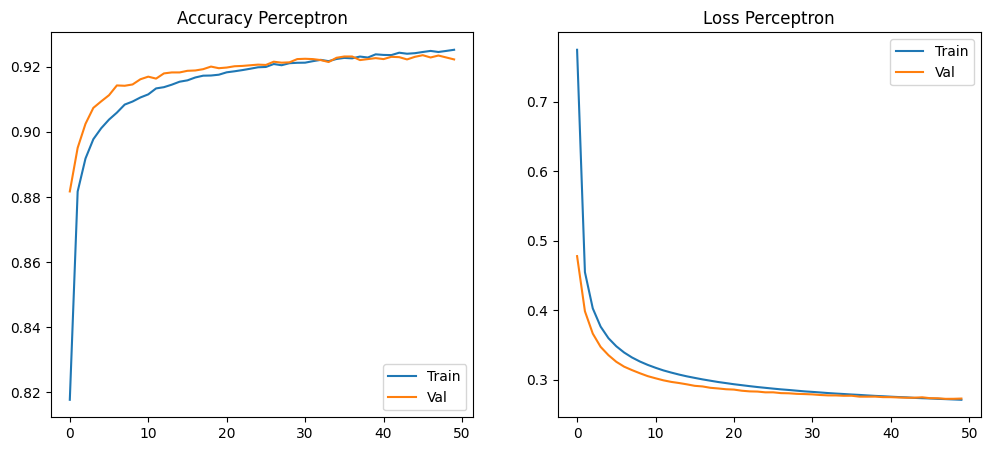

In [34]:
plot_training(hist_percp , "Perceptron")

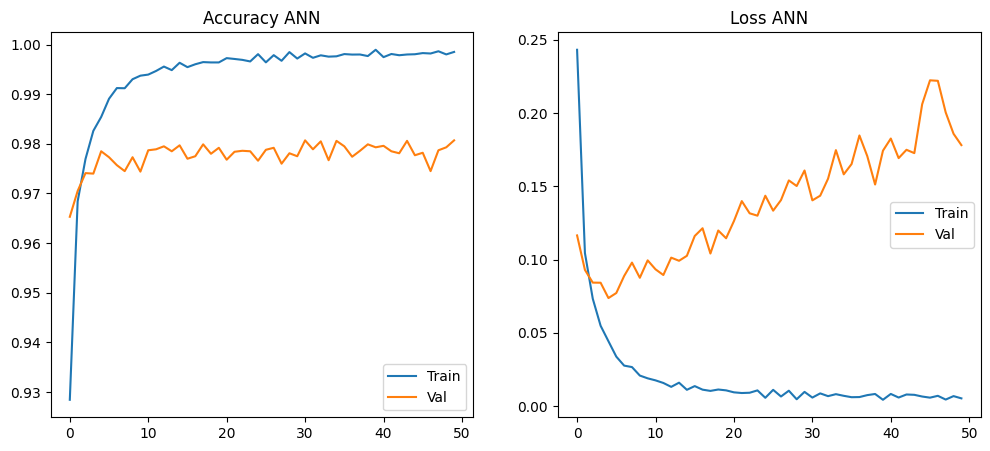

In [35]:
plot_training(history_ann , "ANN")

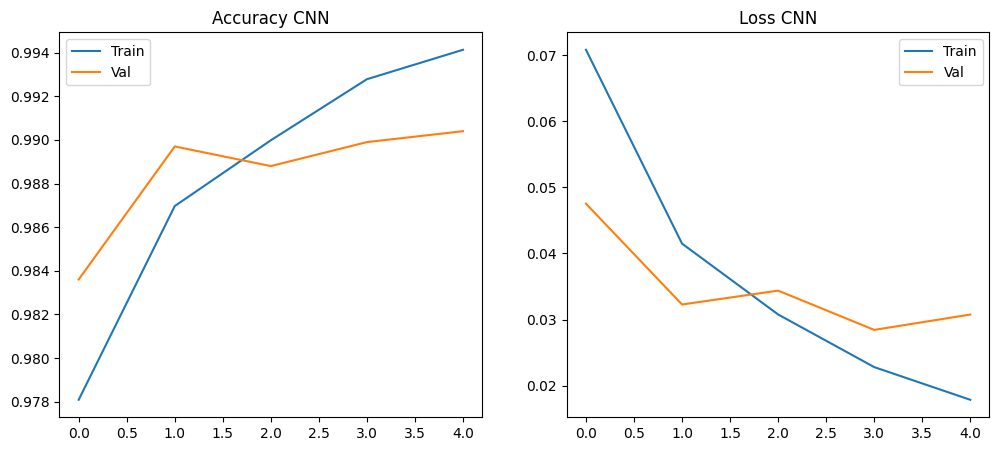

In [36]:
plot_training(history_cnn , "CNN")

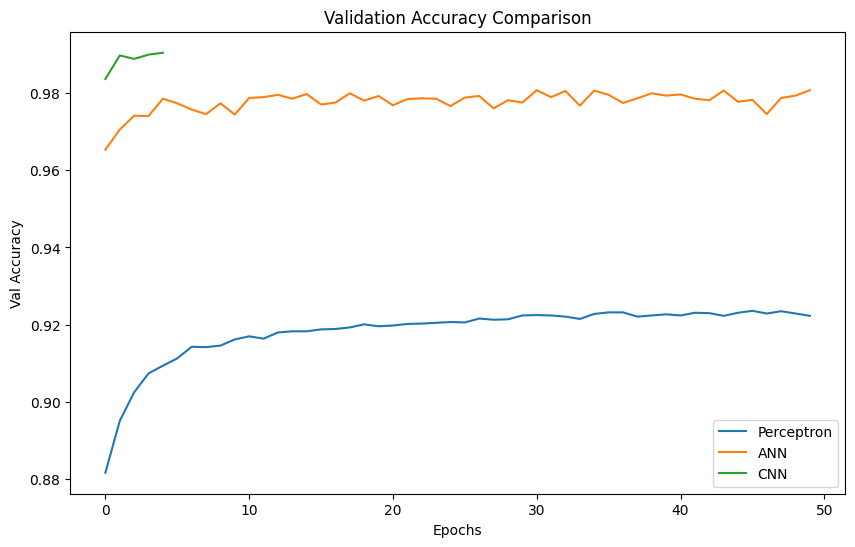

In [37]:
plt.figure(figsize=(10,6))
plt.plot(hist_percp.history['val_accuracy'] , label="Perceptron")
plt.plot(history_ann.history['val_accuracy'] , label="ANN")
plt.plot(history_cnn.history['val_accuracy'] , label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [39]:
def show_side_by_side(models , model_name , X , X_cnn , y_true , n=5):
  idxs = np.random.choice(len(X) , n , replace=False)
  plt.figure(figsize=(15,6))
  for i , idx in enumerate(idxs):
    plt.subplot(2,n,i+1)
    plt.imshow(X[idx].reshape(28,28) , cmap="gray")
    plt.axis("off")
    plt.title(f"True: {y_true[idx]}")
    preds = [np.argmax(model.predict(X_cnn[idx].reshape(1 , 28 , 28 , 1) if
    name == "CNN" else X[idx].reshape(1 , 28 , 28)))
                for model , name , in zip(models , model_name)]
    plt.subplot(2 , n , n+i+1)
    plt.axis("off")
    plt.title("\n" .join(f"{n}: {p}" for n, p in zip(model_name , preds)))
  plt.tight_layout()
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


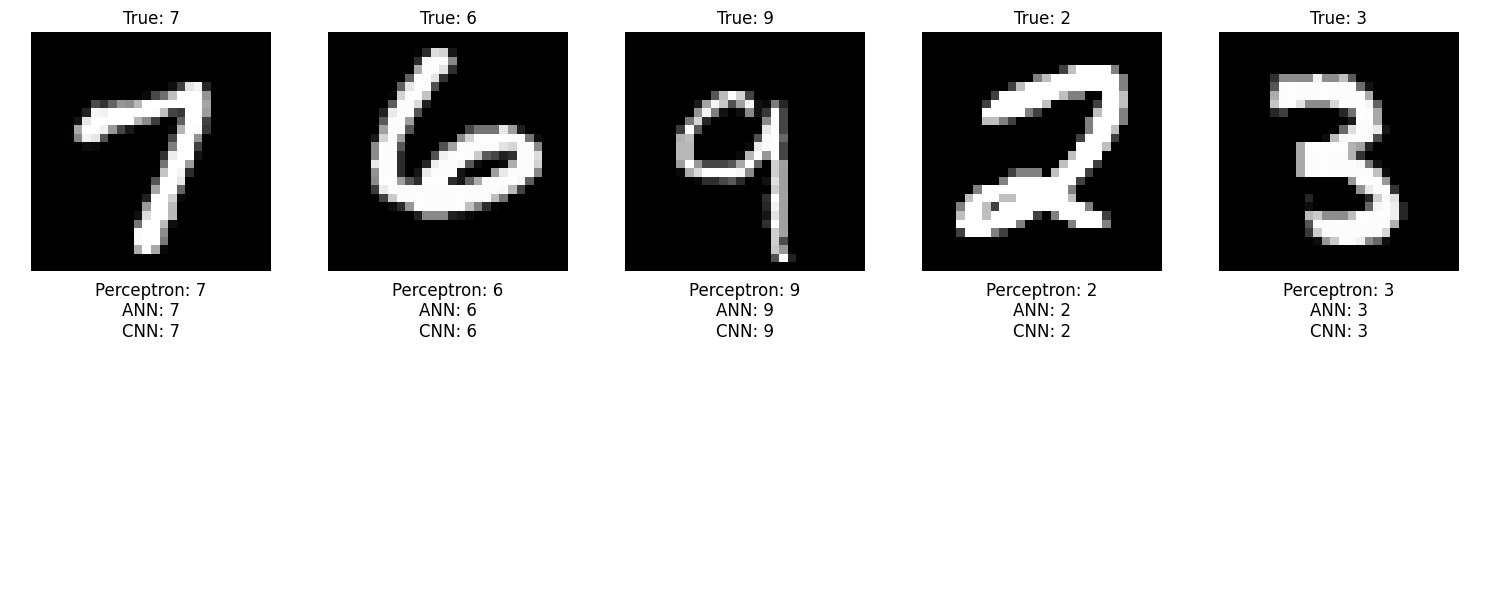

In [44]:
show_side_by_side([perceptron , ann , cnn] , ["Perceptron" , "ANN" , "CNN"] , X_test , X_test_cnn , y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


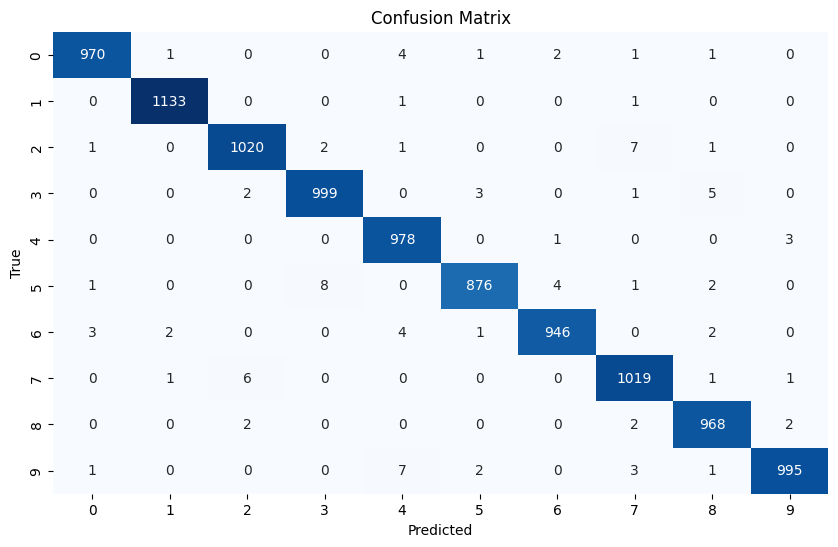

In [45]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn) , axis=1)
cm = confusion_matrix(y_test , y_pred_cnn)
plt.figure(figsize=(10,6))
sns.heatmap(cm , annot=True , fmt="d" , cmap="Blues" , cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

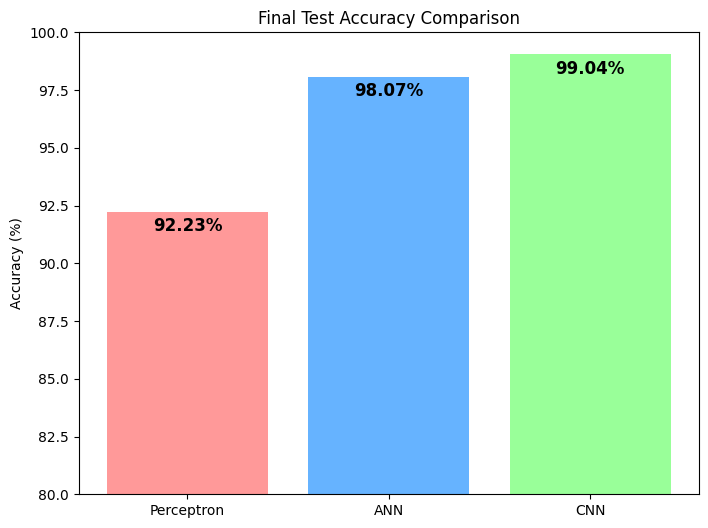

In [46]:
final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()